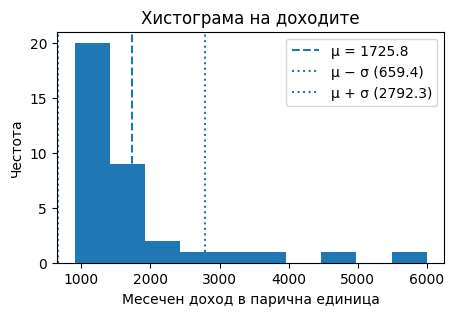

In [1]:
import matplotlib.pyplot as plt
import numpy as np
data = [
    900, 950, 980, 1000, 1020, 1050, 1080, 1100, 1120, 1150,
    1180, 1200, 1220, 1250, 1280, 1300, 1320, 1350, 1380, 1400,
    1450, 1500, 1550, 1600, 1650, 1700, 1750, 1800, 1900, 2000,
    2200, 2500, 3000, 3800, 4500, 6000
]
# Средна стойност и стандартно отклонение
mean = np.mean(data)
std = np.std(data, ddof=1)

plt.figure(figsize=(5,3))
plt.hist(data, bins=10)

# Вертикални линии за μ и ±σ
plt.axvline(mean, linestyle='--', label=f'μ = {mean:.1f}')
plt.axvline(mean - std, linestyle=':', label=f'μ − σ ({mean - std:.1f})')
plt.axvline(mean + std, linestyle=':', label=f'μ + σ ({mean + std:.1f})')

plt.xlabel("Месечен доход в парична единица")
plt.ylabel("Честота")
plt.title("Хистограма на доходите")
plt.legend()
plt.show()


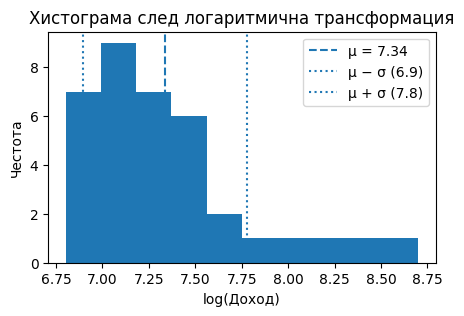

In [2]:
# Логаритмична трансформация (натурален логаритъм)
log_data = np.log(data)
mean_log = np.mean(log_data)
std_log = np.std(log_data, ddof=1)

# --- Хистограма след логаритмична трансформация ---
plt.figure(figsize=(5,3))
plt.hist(log_data, bins=10)
plt.axvline(mean_log, linestyle='--', label=f'μ = {mean_log:.2f}')
plt.axvline(mean_log - std_log, linestyle=':', label=f'μ − σ ({mean_log - std_log:.1f})')
plt.axvline(mean_log + std_log, linestyle=':', label=f'μ + σ ({mean_log + std_log:.1f})')

plt.xlabel("log(Доход)")
plt.ylabel("Честота")
plt.title("Хистограма след логаритмична трансформация")
plt.legend()
plt.show()

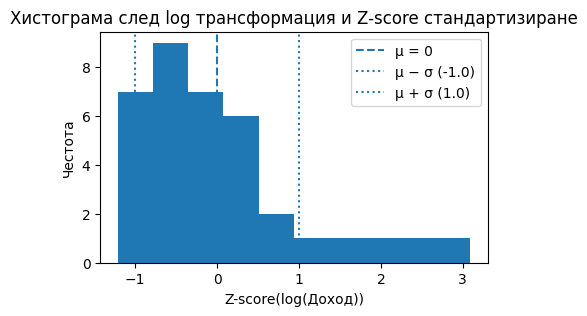

Средна стойност: 0.00
Стандартно отклонение: 1.00


In [3]:
# Логаритмична трансформация
log_data = np.log(data)

# Z-score стандартизиране
mean_log = np.mean(log_data)
std_log = np.std(log_data, ddof=1)
z_log = (log_data - mean_log) / std_log

# Проверка
mean_z = np.mean(z_log)
std_z = np.std(z_log, ddof=1)

# Хистограма на Z-score(log)
plt.figure(figsize=(5,3))
plt.hist(z_log, bins=10)
plt.axvline(0, linestyle='--', label='μ = 0')
plt.axvline(-1, linestyle=':', label=f'μ − σ ({mean_z - std_z:.1f})')
plt.axvline(1, linestyle=':', label=f'μ + σ ({mean_z + std_z:.1f})')
plt.xlabel("Z-score(log(Доход))")
plt.ylabel("Честота")
plt.title("Хистограма след log трансформация и Z-score стандартизиране")
plt.legend()
plt.show()

print(f"Средна стойност: {mean_z:.2f}")
print(f"Стандартно отклонение: {std_z:.2f}")


### 

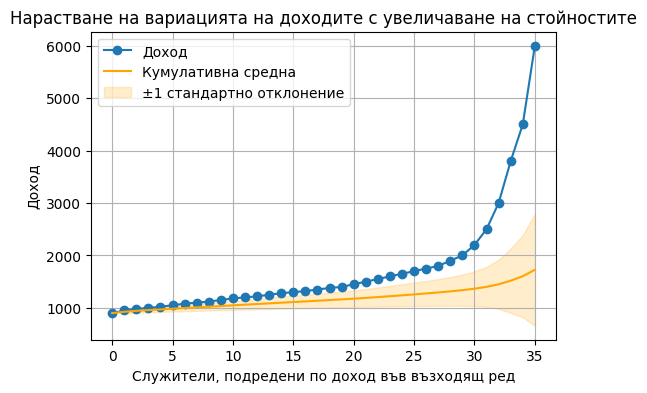

In [5]:
# Сортираме доходите възходящо
data_sorted = np.sort(data)

# Кумулативна средна и стандартно отклонение
cumulative_mean = [np.mean(data_sorted[:i+1]) for i in range(len(data_sorted))]
cumulative_std = [np.std(data_sorted[:i+1], ddof=1) for i in range(len(data_sorted))]  # ddof=1 за sample std

# Графика
plt.figure(figsize=(6,4))
plt.plot(data_sorted, label='Доход', marker='o')
plt.plot(cumulative_mean, label='Кумулативна средна', color='orange')
plt.fill_between(range(len(data_sorted)),
                 np.array(cumulative_mean)-np.array(cumulative_std),
                 np.array(cumulative_mean)+np.array(cumulative_std),
                 color='orange', alpha=0.2, label='±1 стандартно отклонение')

plt.xlabel('Служители, подредени по доход във възходящ ред')
plt.ylabel('Доход')
plt.title('Нарастване на вариацията на доходите с увеличаване на стойностите')
plt.legend()
plt.grid(True)
plt.show()


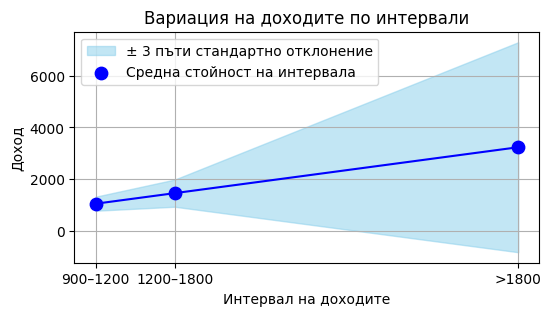

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Интервали и средни
intervals = ['900–1200', '1200–1800', '>1800']
midpoints = [1060.83, 1468.75, 3237.50]  # средните в интервалите за визуализация
std_dev = [3*89.95, 3*174.54, 3*1348.09]  # стандартно отклонение за фунията

# Графика
plt.figure(figsize=(6,3))

# Фуния ±3 стандартни отклонения
plt.fill_between(midpoints,
                 np.array(midpoints) - np.array(std_dev),
                 np.array(midpoints) + np.array(std_dev),
                 color='skyblue', alpha=0.5, label='± 3 пъти стандартно отклонение')

# Линия за средните
plt.plot(midpoints, midpoints, marker='o', linestyle='-', color='blue')

# Отделни точки за средните на интервалите
plt.scatter(midpoints, midpoints, color='blue', s=80, zorder=5, label='Средна стойност на интервала')

# Настройка на оси
plt.xticks(midpoints, intervals)
plt.xlabel('Интервал на доходите')
plt.ylabel('Доход')
plt.title('Вариация на доходите по интервали')
plt.legend()
plt.grid(True)
plt.show()


In [39]:
print (1348.09/ 3237.50)

0.41639845559845556


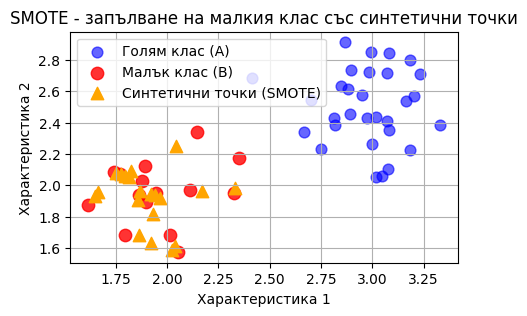

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# -----------------------------
# По-близки класове с повече точки
# -----------------------------
np.random.seed(42)

# Малък клас (class 1) – 15 точки около (2,2)
X_minority = np.random.multivariate_normal(mean=[2,2], cov=[[0.05,0],[0,0.05]], size=15)

# Голям клас (class 0) – 30 точки около (3,2.5)
X_majority = np.random.multivariate_normal(mean=[3,2.5], cov=[[0.05,0],[0,0.05]], size=30)

# -----------------------------
# SMOTE – генерираме 20 синтетични точки
# -----------------------------
n_synthetic = 20
k_neighbors = 3
synthetic_points = []

# Намираме k-съседи за малкия клас
nbrs = NearestNeighbors(n_neighbors=k_neighbors+1).fit(X_minority)
distances, indices = nbrs.kneighbors(X_minority)

for _ in range(n_synthetic):
    idx = np.random.randint(0, X_minority.shape[0])
    x_i = X_minority[idx]
    neighbor_idx = np.random.choice(indices[idx][1:])
    x_j = X_minority[neighbor_idx]
    rand = np.random.rand()
    x_new = x_i + rand * (x_j - x_i)
    synthetic_points.append(x_new)

synthetic_points = np.array(synthetic_points)

# -----------------------------
# Визуализация
# -----------------------------
plt.figure(figsize=(5,3))

# Голям клас
plt.scatter(X_majority[:,0], X_majority[:,1], color='blue', label='Голям клас (A)', s=60, alpha=0.6)

# Малък клас
plt.scatter(X_minority[:,0], X_minority[:,1], color='red', label='Малък клас (B)', s=80, alpha=0.8)

# Синтетични точки
plt.scatter(synthetic_points[:,0], synthetic_points[:,1], color='orange', label='Синтетични точки (SMOTE)', s=80, marker='^')

plt.xlabel('Характеристика 1')
plt.ylabel('Характеристика 2')
plt.title('SMOTE - запълване на малкия клас със синтетични точки')
plt.legend()
plt.grid(True)
plt.show()
